## Importing Libraries

In [ ]:
pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 148.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [ ]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from collections import defaultdict

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = '/content/drive/MyDrive/ECG_Processed_Dataset'

## Original Metadata with signals

In [ ]:
meta = pd.read_csv(f"{DATASET_PATH}/ecg_meta.csv")
signals = np.load(f"{DATASET_PATH}/ecg_signals.npy", allow_pickle=True)

meta["signal"] = signals
df = meta

In [ ]:
df

,record_id,label,length,signal
0,A00001,N,9000,"[-0.127, -0.162, -0.197, -0.229, -0.245, -0.25..."
1,A00002,N,9000,"[0.128, 0.157, 0.189, 0.226, 0.25, 0.257, 0.26..."
2,A00003,N,18000,"[0.056, 0.073, 0.085, 0.093, 0.1, 0.107, 0.113..."
3,A00004,A,9000,"[0.519, 0.619, 0.723, 0.827, 0.914, 0.956, 0.9..."
4,A00005,A,18000,"[-0.188, -0.239, -0.274, -0.316, -0.356, -0.37..."
...,...,...,...,...
8523,A08524,N,9000,"[-0.104, -0.127, -0.144, -0.154, -0.16, -0.164..."
8524,A08525,O,9000,"[-0.121, -0.197, -0.288, -0.39, -0.496, -0.6, ..."
8525,A08526,N,10904,"[-0.202, -0.235, -0.272, -0.305, -0.325, -0.33..."
8526,A08527,N,9000,"[-0.227, -0.297, -0.374, -0.449, -0.505, -0.52..."


In [ ]:
df['signal'][3440]

array([0.028, 0.031, 0.033, ..., 0.006, 0.004, 0.003])

## Windowed Metadata with signals

In [ ]:
signals = np.load(f"{DATASET_PATH}/windowed_signals_9000.npy")
meta = pd.read_csv(f"{DATASET_PATH}/windowed_metadata.csv")

meta["signal"] = list(signals)
windowed_df = meta

In [ ]:
windowed_df

,record_id,window_id,label,label_id,signal
0,A00001,0,N,0.0,"[-0.864847801274676, -1.072787545498718, -1.28..."
1,A00002,0,N,0.0,"[0.6043533214359804, 0.7685190906833443, 0.949..."
2,A00003,0,N,0.0,"[0.42090414235866846, 0.5348628202637852, 0.61..."
3,A00003,1,N,0.0,"[0.15276607669957007, 0.15946952834104752, 0.1..."
4,A00004,0,A,NaN,"[2.2397562185223023, 2.707878323598838, 3.1947..."
...,...,...,...,...,...
9371,A08524,0,N,0.0,"[-1.8868168948556805, -2.271787061141514, -2.5..."
9372,A08525,0,O,2.0,"[-0.17081191205058835, -0.41130887348926887, -..."
9373,A08526,0,N,0.0,"[-1.2866328515666983, -1.4831286761972158, -1...."
9374,A08527,0,N,0.0,"[-1.1545600565588832, -1.506429297777834, -1.8..."


In [ ]:
windowed_df['signal'][0]

array([-0.8648478 , -1.07278755, -1.28072729, ..., -0.21726403,
       -0.24102857, -0.23508743])

In [ ]:
label_encoding = {
    "N": 0,
    "A": 1,   # FIXED
    "O": 2,
    "~": 3
}

windowed_df["label_id"] = windowed_df["label"].map(label_encoding)

In [ ]:
print(windowed_df["label_id"].unique())
# should be [0, 1, 2, 3]

[0 1 2 3]


# Preparing Data for Training

In [ ]:
X = np.stack(windowed_df["signal"].values)
y = windowed_df["label_id"].values

# Add channel dimension for Conv1D
X = X[..., np.newaxis]

print(X.shape)  # (num_windows, 9000, 1)
print(y.shape)

(9376, 9000, 1)
(9376,)


In [ ]:
record_labels = (
    windowed_df
    .groupby("record_id")["label_id"]
    .first()
)

from sklearn.model_selection import train_test_split

train_records, val_records = train_test_split(
    record_labels.index.values,
    test_size=0.2,
    random_state=42,
    stratify=record_labels.values
)

train_idx = windowed_df["record_id"].isin(train_records)
val_idx   = windowed_df["record_id"].isin(val_records)

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]


In [ ]:
print("Train labels:", np.unique(y_train))
print("Val labels:", np.unique(y_val))

Train labels: [0 1 2 3]
Val labels: [0 1 2 3]


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

all_classes = np.array([0, 1, 2, 3])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=all_classes,
    y=y_train
)

class_weight_dict = dict(zip(all_classes, class_weights))
print(class_weight_dict)


{np.int64(0): np.float64(0.4298305860805861), np.int64(1): np.float64(2.8022388059701493), np.int64(2): np.float64(0.8377956269522535), np.int64(3): np.float64(8.127705627705629)}


In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)


X_train shape: (7510, 9000, 1)
y_train shape: (7510,)
X_val shape: (1866, 9000, 1)
y_val shape: (1866,)


In [ ]:
class_weight_dict


{np.int64(0): np.float64(0.4298305860805861),
 np.int64(1): np.float64(2.8022388059701493),
 np.int64(2): np.float64(0.8377956269522535),
 np.int64(3): np.float64(8.127705627705629)}

# DL

## TCN

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Conv1D, BatchNormalization, Activation,
    Dropout, Add
)

In [ ]:
def tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout=0.2):
    shortcut = x

    x = Conv1D(
        filters,
        kernel_size,
        padding="causal",
        dilation_rate=dilation_rate
    )(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(dropout)(x)

    x = Conv1D(
        filters,
        kernel_size,
        padding="causal",
        dilation_rate=dilation_rate
    )(x)
    x = BatchNormalization()(x)

    # Match channels if needed
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding="same")(shortcut)

    x = Add()([shortcut, x])
    x = Activation("relu")(x)

    return x


In [ ]:
from tensorflow.keras.layers import (
    Input, GlobalAveragePooling1D, Dense
)
from tensorflow.keras.models import Model

def build_tcn(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = inputs
    for dilation_rate in [1, 2, 4, 8, 16]:
        x = tcn_residual_block(
            x,
            filters=64,
            kernel_size=7,
            dilation_rate=dilation_rate
        )

    x = GlobalAveragePooling1D()(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model


In [ ]:
window_length = 9000

In [ ]:
model_tcn = build_tcn(
    input_shape=(window_length, 1),
    num_classes=4
)

model_tcn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_tcn.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 9000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 9000, 64)  │        512 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 9000, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 9000, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 9000, 64)  │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 9000, 64)  │     28,736 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 9000, 64)  │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9000, 64)  │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 9000, 64)  │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 9000, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 9000, 64)  │     28,736 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9000, 64)  │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 9000, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 9000, 64)  │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 9000, 64)  │     28,736 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9000, 64)  │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 9000, 64)  │          0 │ activation_1[0][… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 9000, 64)  │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 9000, 64)  │     28,736 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 262,084 (1023.77 KB)

 Trainable params: 260,804 (1018.77 KB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5
    ),
    ModelCheckpoint(
        "tcn_best_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]


In [ ]:
history = model_tcn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 113s 381ms/step - accuracy: 0.4000 - loss: 1.1769 - val_accuracy: 0.2953 - val_loss: 1.3750 - learning_rate: 0.0010
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 75s 318ms/step - accuracy: 0.5797 - loss: 0.8281 - val_accuracy: 0.4673 - val_loss: 1.0875 - learning_rate: 0.0010
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 74s 316ms/step - accuracy: 0.6227 - loss: 0.7587 - val_accuracy: 0.3612 - val_loss: 1.3994 - learning_rate: 0.0010
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 74s 316ms/step - accuracy: 0.6353 - loss: 0.6964 - val_accuracy: 0.4427 - val_loss: 1.1399 - learning_rate: 0.0010
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 74s 317ms/step - accuracy: 0.6646 - loss: 0.6622 - val_accuracy: 0.7031 - val_loss: 0.7183 - learning_rate: 0.0010
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 74s 316ms/step - accuracy: 0.6510 - loss: 0.6704 - val_accuracy: 0.6715 - val_loss: 0.8245 - learning_rate: 0.0010
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 74s 316ms/step - accuracy: 0.

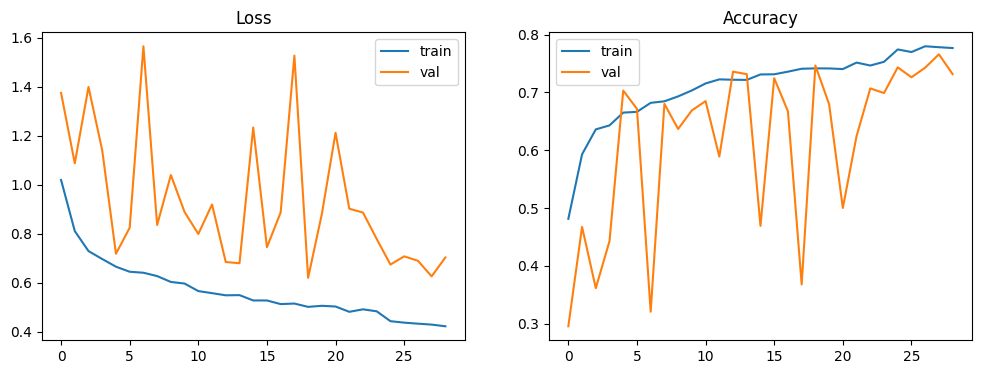

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()

plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model_tcn.predict(X_val)
y_pred_cls = y_pred.argmax(axis=1)

print(classification_report(y_val, y_pred_cls, target_names=["N", "A", "O", "~"]))
print(confusion_matrix(y_val, y_pred_cls))


59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step
              precision    recall  f1-score   support

           N       0.79      0.90      0.84      1090
           A       0.64      0.74      0.69       161
           O       0.76      0.44      0.55       556
           ~       0.39      0.81      0.53        59

    accuracy                           0.75      1866
   macro avg       0.65      0.72      0.65      1866
weighted avg       0.76      0.75      0.73      1866

[[984  14  54  38]
 [ 12 119  21   9]
 [236  51 242  27]
 [  7   2   2  48]]


In [ ]:
import numpy as np
import pandas as pd

val_df = windowed_df[val_idx].copy()
val_df["pred"] = y_pred_cls

record_preds = (
    val_df
    .groupby("record_id")
    .agg(
        true_label=("label_id", "first"),
        pred_label=("pred", lambda x: np.bincount(x).argmax())
    )
)

print(classification_report(
    record_preds["true_label"],
    record_preds["pred_label"],
    target_names=["N", "A", "O", "~"]
))


              precision    recall  f1-score   support

           N       0.80      0.91      0.85      1010
           A       0.65      0.74      0.69       148
           O       0.76      0.41      0.53       491
           ~       0.39      0.81      0.52        57

    accuracy                           0.75      1706
   macro avg       0.65      0.72      0.65      1706
weighted avg       0.76      0.75      0.73      1706



In [ ]:
val_loss, val_accuracy = model_tcn.evaluate(X_val, y_val, verbose=0)

print(f"Final window-level validation accuracy: {val_accuracy:.4f}")


Final window-level validation accuracy: 0.7465
